# Topic 3.2 - Matplotlib 绘制常见的图表

本节开始前，我们先导入 Matplotlib 和其他必要的包，并设置中文字体：

In [38]:
import random
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['STHeiti'] 
plt.rcParams['axes.unicode_minus'] = False 

## 1. 折线图

折线图（Line Chart）通常用于显示数据随时间的变化趋势，在 Matplotlib 中，绘制折线图所需的数据类型可以是多样的：

- 可以是列表、Pandas 的 Series 对象、NumPy 的数组等一维数据结构
- 对于 Pandas 的 DataFrame 对象，最好是使用列名来指定数据，也就是把列提取出来变成 Series 对象

在 Matplotlib 中，绘制折线图可以使用 `plt.plot()` 函数，当中可以强调以下参数：

- 第一个参数是 x 轴数据，通常是 DataFrame 中设置为时间的列或 index
- 第二个参数是 y 轴数据，通常是想要绘制的数值列
- `marker` 参数用于设置数据点的标记样式，默认是无标记，'o' 表示圆圈，'s' 表示方块，'^' 表示三角形，'D' 表示菱形等
- `label` 参数用于设置图例标签，以便在图例中显示不同数据系列的名称

首先我们来看一个一条线的折线图示例：

In [39]:
df1a = pd.DataFrame({
    "A": [random.randint(10, 50) for _ in range(10)],
    "B": [random.randint(20, 60) for _ in range(10)],
    "C": [random.randint(30, 70) for _ in range(10)]
}, index=pd.date_range("2023-01-01", periods=10))

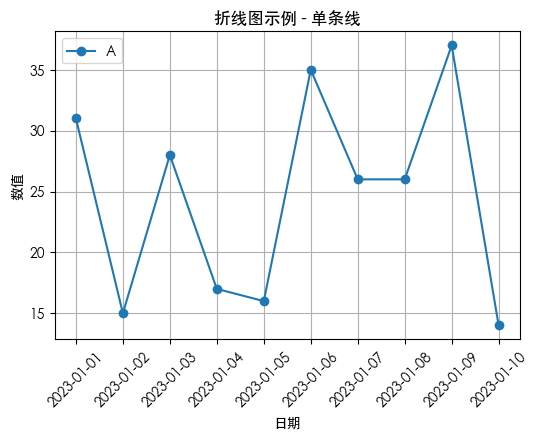

In [40]:
plt.figure(figsize=(6, 4))
plt.plot(df1a.index, df1a['A'], marker='o', label='A')
plt.xticks(rotation=45)
plt.title("折线图示例 - 单条线")
plt.xlabel("日期")
plt.ylabel("数值")
plt.legend()
plt.grid(True)
plt.show()

如果想绘制多条线，只需多次调用 `plt.plot()` 函数即可，例如下面的代码示例：

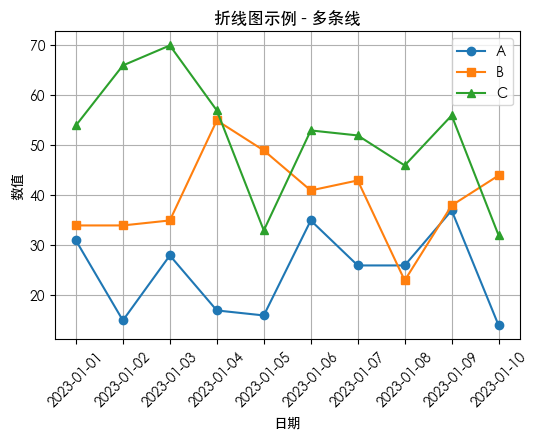

In [41]:
plt.figure(figsize=(6, 4))
plt.plot(df1a.index, df1a['A'], marker='o', label='A')
plt.plot(df1a.index, df1a['B'], marker='s', label='B')
plt.plot(df1a.index, df1a['C'], marker='^', label='C')
plt.xticks(rotation=45)
plt.title("折线图示例 - 多条线")
plt.xlabel("日期")
plt.ylabel("数值")
plt.legend()
plt.grid(True)
plt.show()

如果 x 轴不是时间类型的数据，也可以直接使用数值类型的数据：

In [42]:
df1b = pd.DataFrame({
    "A": [random.randint(10, 50) for _ in range(10)],
    "B": [random.randint(20, 60) for _ in range(10)],
})

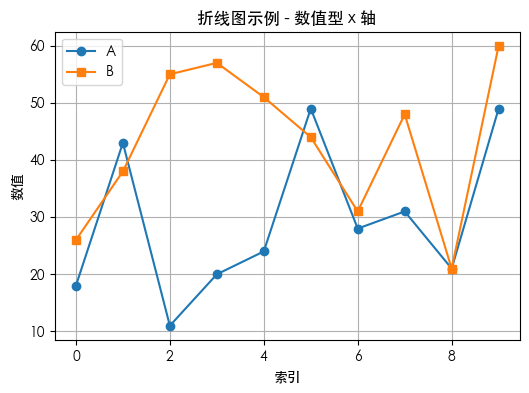

In [43]:
plt.figure(figsize=(6, 4))
plt.plot(df1b.index, df1b['A'], marker='o', label='A')
plt.plot(df1b.index, df1b['B'], marker='s', label='B')
plt.title("折线图示例 - 数值型 x 轴")
plt.xlabel("索引")
plt.ylabel("数值")
plt.legend()
plt.grid(True)
plt.show()

注意，Matplotlib 在画图时，会严格按照数值填充到 x 轴和 y 轴上，就像我们上学时候在坐标轴上画点连线一样：

- 因此，如果 x 轴数据并不是连续的数值，图形可能会出现断点或不均匀的间隔
- 比方说 x 的数据是 [1, 2, 4, 7]，那么在 x=3 和 x=5、6 的位置上就不会有点，线条会直接从 x=2 连到 x=4，然后再从 x=4 连到 x=7
- 如果 x 轴是时间类型的数据，这种情况也同样适用，例如日期中缺少某些天数，图形上也会出现断点
- 出现这种情况时，一定要严格检查 x 轴数据，确保它们是正确且符合预期的

In [44]:
df1b = pd.DataFrame({
    "A": [random.randint(10, 50) for _ in range(5)],
    "B": [random.randint(20, 60) for _ in range(5)],
}, index=[1, 2, 4, 7, 8])

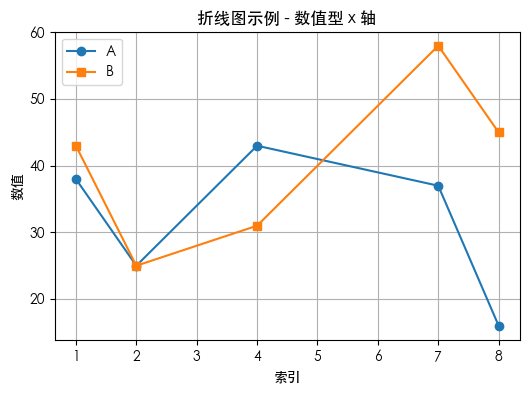

In [45]:
plt.figure(figsize=(6, 4))
plt.plot(df1b.index, df1b['A'], marker='o', label='A')
plt.plot(df1b.index, df1b['B'], marker='s', label='B')
plt.title("折线图示例 - 数值型 x 轴")
plt.xlabel("索引")
plt.ylabel("数值")
plt.legend()
plt.grid(True)
plt.show()